# Netflix Content Analysis — EDA Project

**Author:** Shayan Khan  
**Date:** 2026  
**Dataset:** Netflix Movies and TV Shows (Kaggle — Shivam Bansal)  
**Tools:** Python, Pandas, Matplotlib, Seaborn, WordCloud

---

## Project Goal
Explore the Netflix catalog to understand content trends, geographic distribution,
audience ratings, genre popularity, and how the platform's library evolved over time.

## Structure
1. Data loading & inspection  
2. Data cleaning  
3. Exploratory data analysis  
4. Visualizations  
5. Key insights & conclusions

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [51]:
df = pd.read_csv("netflix_titles.csv")

In [52]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [53]:
df.shape

(8807, 12)

In [54]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [55]:
df.columns.tolist()

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description']

In [56]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [57]:
df.shape

(8807, 12)

In [58]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [59]:
df.describe(include = 'all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [60]:
missing = df.isnull().sum()
missing_pct = (missing/len(df)*100).round(2)

missing_df = pd.DataFrame({
    'Missing Count' : missing,
    'Missing %' : missing_pct
}).sort_values('Missing %', ascending = False)

print(missing_df[missing_df['Missing Count'] >0 ])

            Missing Count  Missing %
director             2634      29.91
country               831       9.44
cast                  825       9.37
date_added             10       0.11
rating                  4       0.05
duration                3       0.03


In [61]:
df['director'] = df['director'].fillna('Unknown')
df['cast']     = df['cast'].fillna('Unknown')

df['country'] = df['country'].fillna(df['country'].mode()[0])

df.dropna(subset=['date_added'], inplace=True)

df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

df.dropna(subset=['duration'], inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [62]:
if df['date_added'].dtype == 'object':
    df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), format='%B %d, %Y')
else:
    df['date_added'] = pd.to_datetime(df['date_added'])

df['year_added']  = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['month_name']  = df['date_added'].dt.strftime('%B')

print(df[['date_added', 'year_added', 'month_added', 'month_name']].head(10))

  date_added  year_added  month_added month_name
0 2021-09-25        2021            9  September
1 2021-09-24        2021            9  September
2 2021-09-24        2021            9  September
3 2021-09-24        2021            9  September
4 2021-09-24        2021            9  September
5 2021-09-24        2021            9  September
6 2021-09-24        2021            9  September
7 2021-09-24        2021            9  September
8 2021-09-24        2021            9  September
9 2021-09-24        2021            9  September


In [63]:


df['duration_value'] = df['duration'].str.extract(r'(\d+)').astype(int)
df['duration_unit']  = df['duration'].str.extract(r'([A-Za-z]+)')

print(df[['type', 'duration', 'duration_value', 'duration_unit']].head(10))

      type   duration  duration_value duration_unit
0    Movie     90 min              90           min
1  TV Show  2 Seasons               2       Seasons
2  TV Show   1 Season               1        Season
3  TV Show   1 Season               1        Season
4  TV Show  2 Seasons               2       Seasons
5  TV Show   1 Season               1        Season
6    Movie     91 min              91           min
7    Movie    125 min             125           min
8  TV Show  9 Seasons               9       Seasons
9    Movie    104 min             104           min


In [64]:
print("Duplicates before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicates after: ", df.duplicated().sum())

Duplicates before: 0
Duplicates after:  0


In [65]:
print("=== Final Dataset Info ===")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
print(f"\nDate range: {df['date_added'].min()} → {df['date_added'].max()}")
print(f"\nContent types:\n{df['type'].value_counts()}")
print(f"\nUnique countries: {df['country'].nunique()}")
print(f"\nRatings:\n{df['rating'].value_counts()}")

=== Final Dataset Info ===
Rows    : 8794
Columns : 17

Date range: 2008-01-01 00:00:00 → 2021-09-25 00:00:00

Content types:
type
Movie      6128
TV Show    2666
Name: count, dtype: int64

Unique countries: 748

Ratings:
rating
TV-MA       3209
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


In [66]:

df.to_csv('netflix_clean.csv', index=False)
print("Saved as netflix_clean.csv")

Saved as netflix_clean.csv


In [67]:

type_counts = df['type'].value_counts()
print(type_counts)
print(f"\nMovies make up {type_counts['Movie']/len(df)*100:.1f}% of the catalog")
print(f"TV Shows make up {type_counts['TV Show']/len(df)*100:.1f}% of the catalog")

type
Movie      6128
TV Show    2666
Name: count, dtype: int64

Movies make up 69.7% of the catalog
TV Shows make up 30.3% of the catalog


In [68]:

yearly = df['year_added'].value_counts().sort_index()
print("Titles added per year:")
print(yearly)


yearly_type = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
print("\nBy type per year:")
print(yearly_type)

Titles added per year:
year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     427
2017    1187
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

By type per year:
type        Movie  TV Show
year_added                
2008            1        1
2009            2        0
2010            1        0
2011           13        0
2012            3        0
2013            6        5
2014           19        5
2015           56       26
2016          251      176
2017          838      349
2018         1237      412
2019         1424      592
2020         1284      595
2021          993      505


In [69]:

from collections import Counter

all_countries = df['country'].dropna().str.split(', ').explode()
top_countries = all_countries.value_counts().head(15)

print("Top 15 content-producing countries:")
print(top_countries)

Top 15 content-producing countries:
country
United States     4510
India             1046
United Kingdom     803
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Mexico             169
China              162
Australia          159
Egypt              117
Turkey             113
Hong Kong          105
Name: count, dtype: int64


In [70]:
rating_counts = df['rating'].value_counts()
print("Rating distribution:")
print(rating_counts)

Rating distribution:
rating
TV-MA       3209
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


In [71]:

all_genres = df['listed_in'].str.split(', ').explode()
top_genres = all_genres.value_counts().head(15)

print("Top 15 genres on Netflix:")
print(top_genres)

Top 15 genres on Netflix:
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Thrillers                    577
TV Comedies                  574
Crime TV Shows               469
Kids' TV                     449
Docuseries                   394
Name: count, dtype: int64


In [72]:
movies = df[df['type'] == 'Movie'].copy()
shows  = df[df['type'] == 'TV Show'].copy()

print("=== Movie Duration (minutes) ===")
print(movies['duration_value'].describe())
print(f"\nShortest movie : {movies['duration_value'].min()} min")
print(f"Longest movie  : {movies['duration_value'].max()} min")
print(f"Average movie  : {movies['duration_value'].mean():.0f} min")

print("\n=== TV Show Seasons ===")
print(shows['duration_value'].describe())
print(f"\nMost seasons a show has: {shows['duration_value'].max()}")

=== Movie Duration (minutes) ===
count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_value, dtype: float64

Shortest movie : 3 min
Longest movie  : 312 min
Average movie  : 100 min

=== TV Show Seasons ===
count    2666.000000
mean        1.751313
std         1.550176
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: duration_value, dtype: float64

Most seasons a show has: 17


In [73]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly = df['month_name'].value_counts().reindex(month_order)
print("Content added by month:")
print(monthly)
print(f"\nBusiest month: {monthly.idxmax()} ({monthly.max()} titles)")
print(f"Quietest month: {monthly.idxmin()} ({monthly.min()} titles)")

Content added by month:
month_name
January      738
February     563
March        742
April        763
May          632
June         728
July         827
August       754
September    769
October      760
November     705
December     813
Name: count, dtype: int64

Busiest month: July (827 titles)
Quietest month: February (563 titles)


In [74]:
top_directors = (df[df['director'] != 'Unknown']['director']
                 .value_counts()
                 .head(10))
print("Top 10 most prolific directors on Netflix:")
print(top_directors)

Top 10 most prolific directors on Netflix:
director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Jay Chapman               12
Martin Scorsese           12
Youssef Chahine           12
Steven Spielberg          11
Name: count, dtype: int64


In [75]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')


plt.rcParams['figure.dpi']      = 120
plt.rcParams['figure.figsize']  = (12, 5)
plt.rcParams['font.family']     = 'DejaVu Sans'

NETFLIX_RED = '#E50914'
COLORS      = ['#E50914','#221F1F','#B81D24','#F5F5F1','#564d4d']

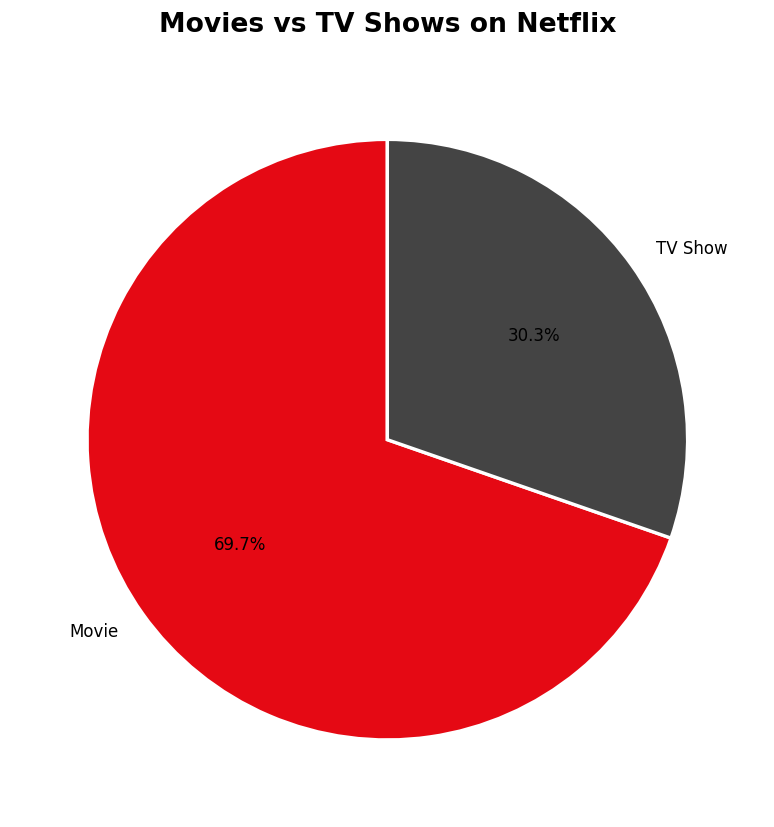

In [76]:
fig, ax = plt.subplots(figsize=(7, 7))
type_counts = df['type'].value_counts()

ax.pie(type_counts,
       labels=type_counts.index,
       autopct='%1.1f%%',
       colors=[NETFLIX_RED, '#444'],
       startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})

ax.set_title('Movies vs TV Shows on Netflix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('chart1_type_split.png', bbox_inches='tight')
plt.show()

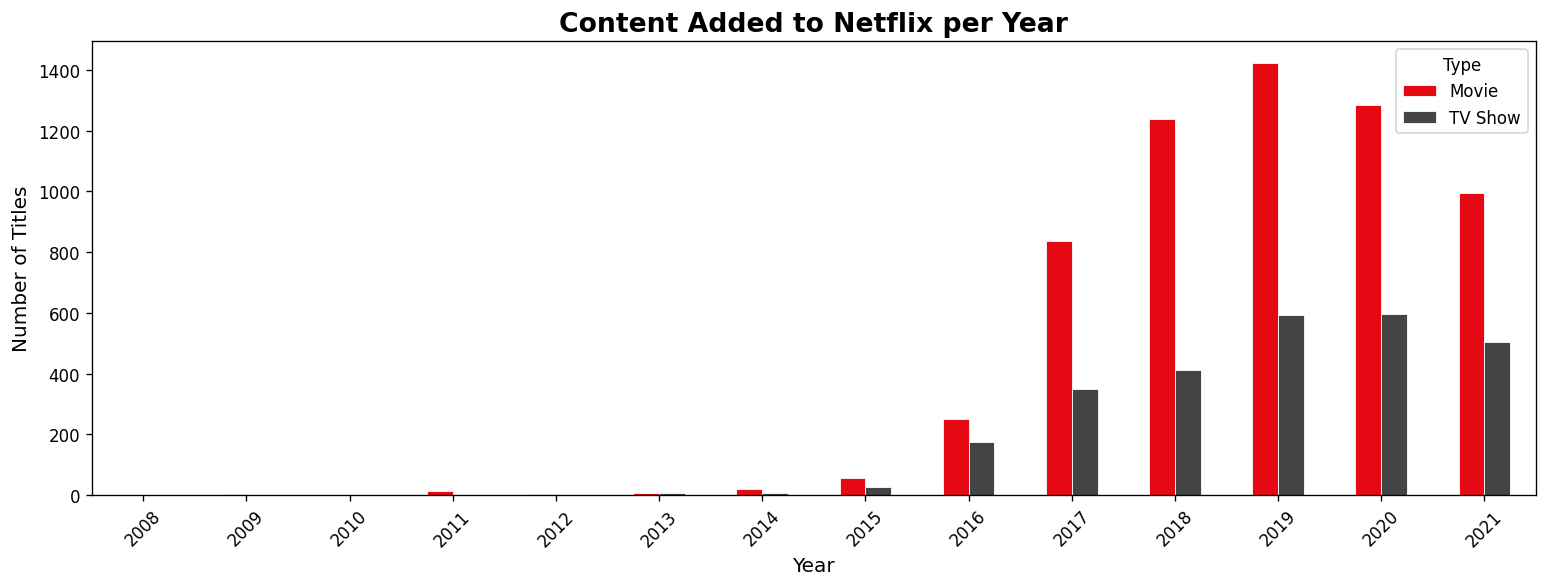

In [77]:
yearly_type = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(13, 5))
yearly_type.plot(kind='bar', ax=ax,
                 color=[NETFLIX_RED, '#444'],
                 edgecolor='white', linewidth=0.5)

ax.set_title('Content Added to Netflix per Year', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Titles', fontsize=12)
ax.legend(title='Type')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('chart2_yearly_additions.png', bbox_inches='tight')
plt.show()

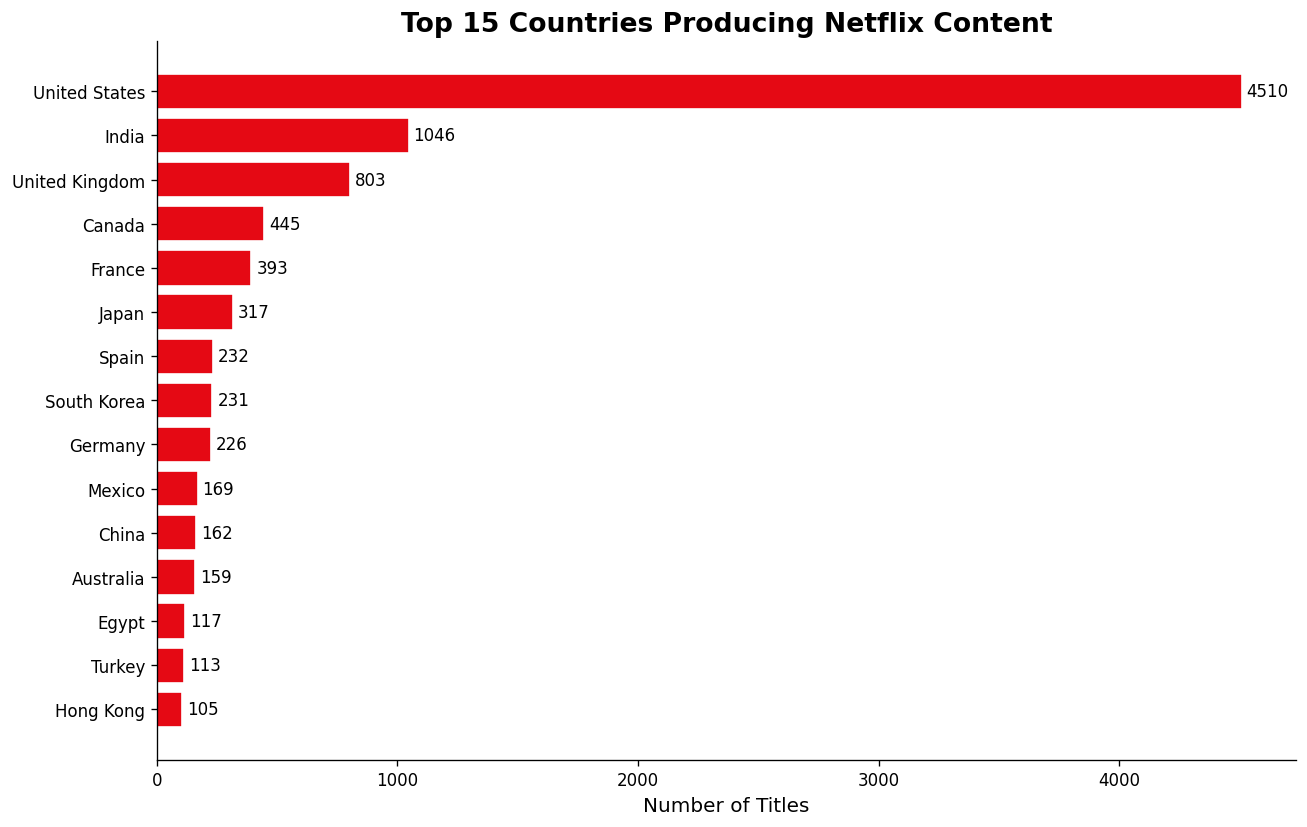

In [78]:
all_countries = df['country'].dropna().str.split(', ').explode()
top_countries = all_countries.value_counts().head(15)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1],
               color=NETFLIX_RED, edgecolor='white')

for bar, val in zip(bars, top_countries.values[::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)

ax.set_title('Top 15 Countries Producing Netflix Content', fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Titles', fontsize=12)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart3_top_countries.png', bbox_inches='tight')
plt.show()

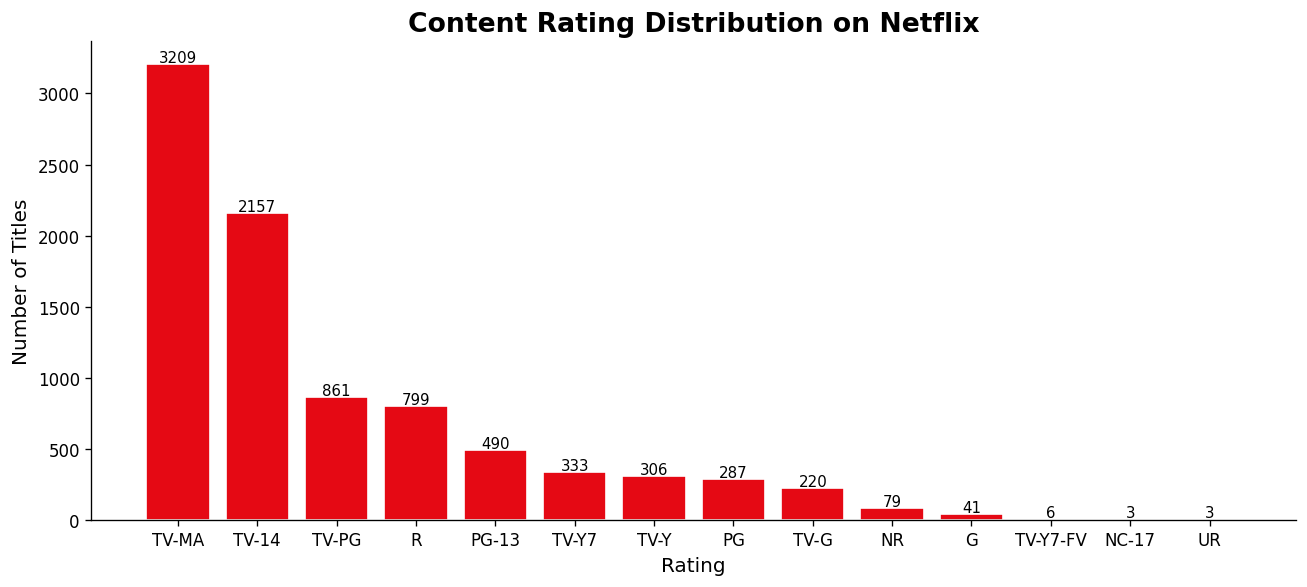

In [79]:
rating_counts = df['rating'].value_counts()

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(rating_counts.index, rating_counts.values,
              color=NETFLIX_RED, edgecolor='white')

for bar, val in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(val), ha='center', fontsize=9)

ax.set_title('Content Rating Distribution on Netflix', fontsize=16, fontweight='bold')
ax.set_xlabel('Rating', fontsize=12)
ax.set_ylabel('Number of Titles', fontsize=12)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart4_ratings.png', bbox_inches='tight')
plt.show()

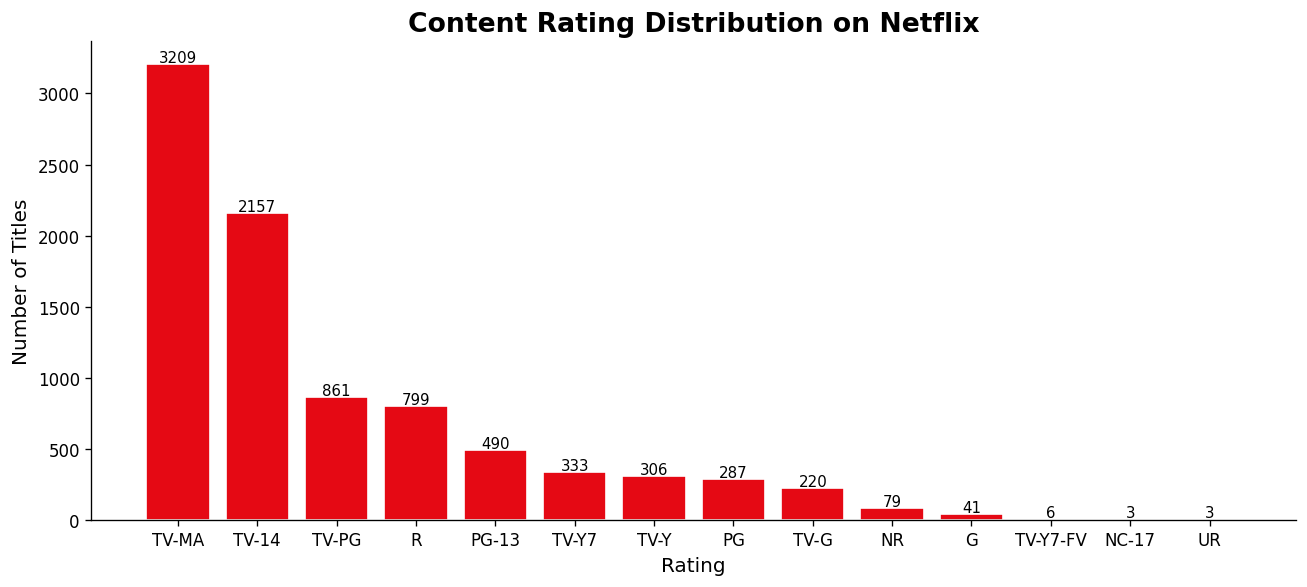

In [80]:
rating_counts = df['rating'].value_counts()

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(rating_counts.index, rating_counts.values,
              color=NETFLIX_RED, edgecolor='white')

for bar, val in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(val), ha='center', fontsize=9)

ax.set_title('Content Rating Distribution on Netflix', fontsize=16, fontweight='bold')
ax.set_xlabel('Rating', fontsize=12)
ax.set_ylabel('Number of Titles', fontsize=12)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart4_ratings.png', bbox_inches='tight')
plt.show()

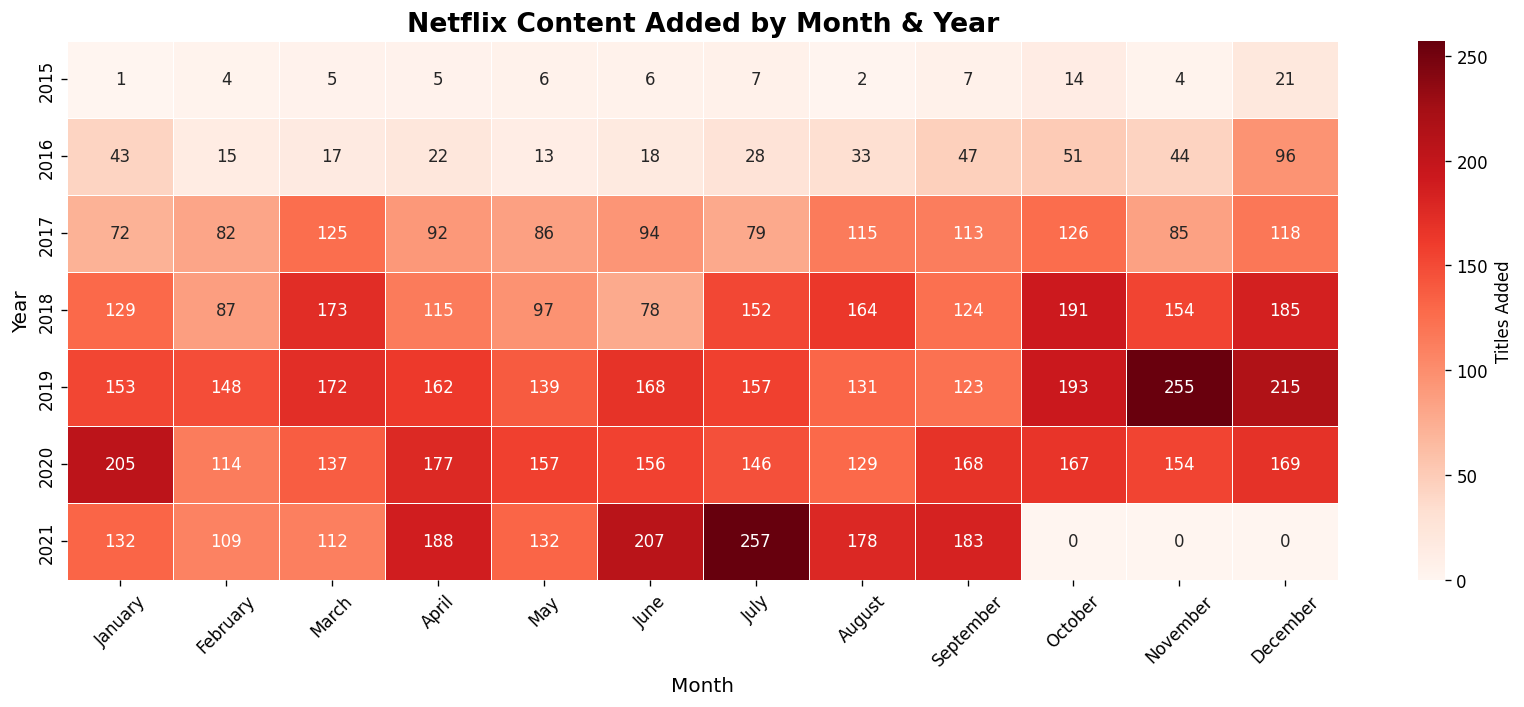

In [81]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

heat_data = (df.groupby(['year_added', 'month_name'])
               .size()
               .unstack(fill_value=0)
               .reindex(columns=month_order))

heat_data = heat_data[heat_data.index >= 2015]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heat_data,
            cmap='Reds',
            linewidths=0.5,
            linecolor='white',
            annot=True,
            fmt='d',
            ax=ax,
            cbar_kws={'label': 'Titles Added'})

ax.set_title('Netflix Content Added by Month & Year', fontsize=16, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Year', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('chart6_heatmap.png', bbox_inches='tight')
plt.show()

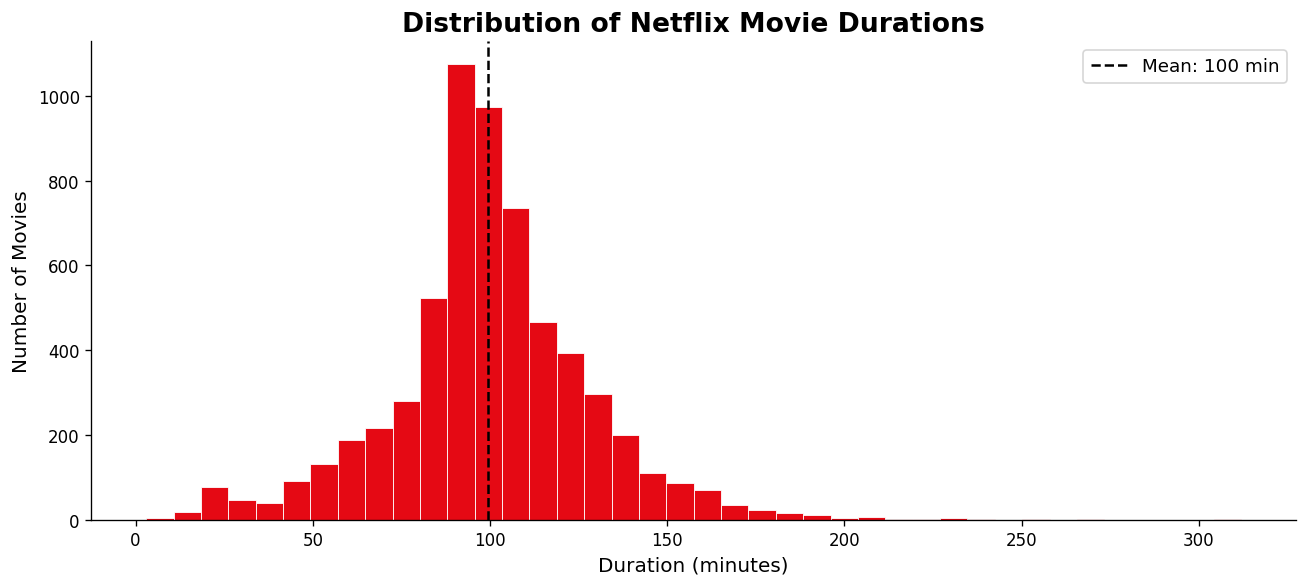

In [82]:
movies = df[df['type'] == 'Movie']

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(movies['duration_value'].dropna(), bins=40,
        color=NETFLIX_RED, edgecolor='white', linewidth=0.5)

ax.axvline(movies['duration_value'].mean(), color='black',
           linestyle='--', linewidth=1.5,
           label=f"Mean: {movies['duration_value'].mean():.0f} min")

ax.set_title('Distribution of Netflix Movie Durations', fontsize=16, fontweight='bold')
ax.set_xlabel('Duration (minutes)', fontsize=12)
ax.set_ylabel('Number of Movies', fontsize=12)
ax.legend(fontsize=11)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart7_movie_duration.png', bbox_inches='tight')
plt.show()

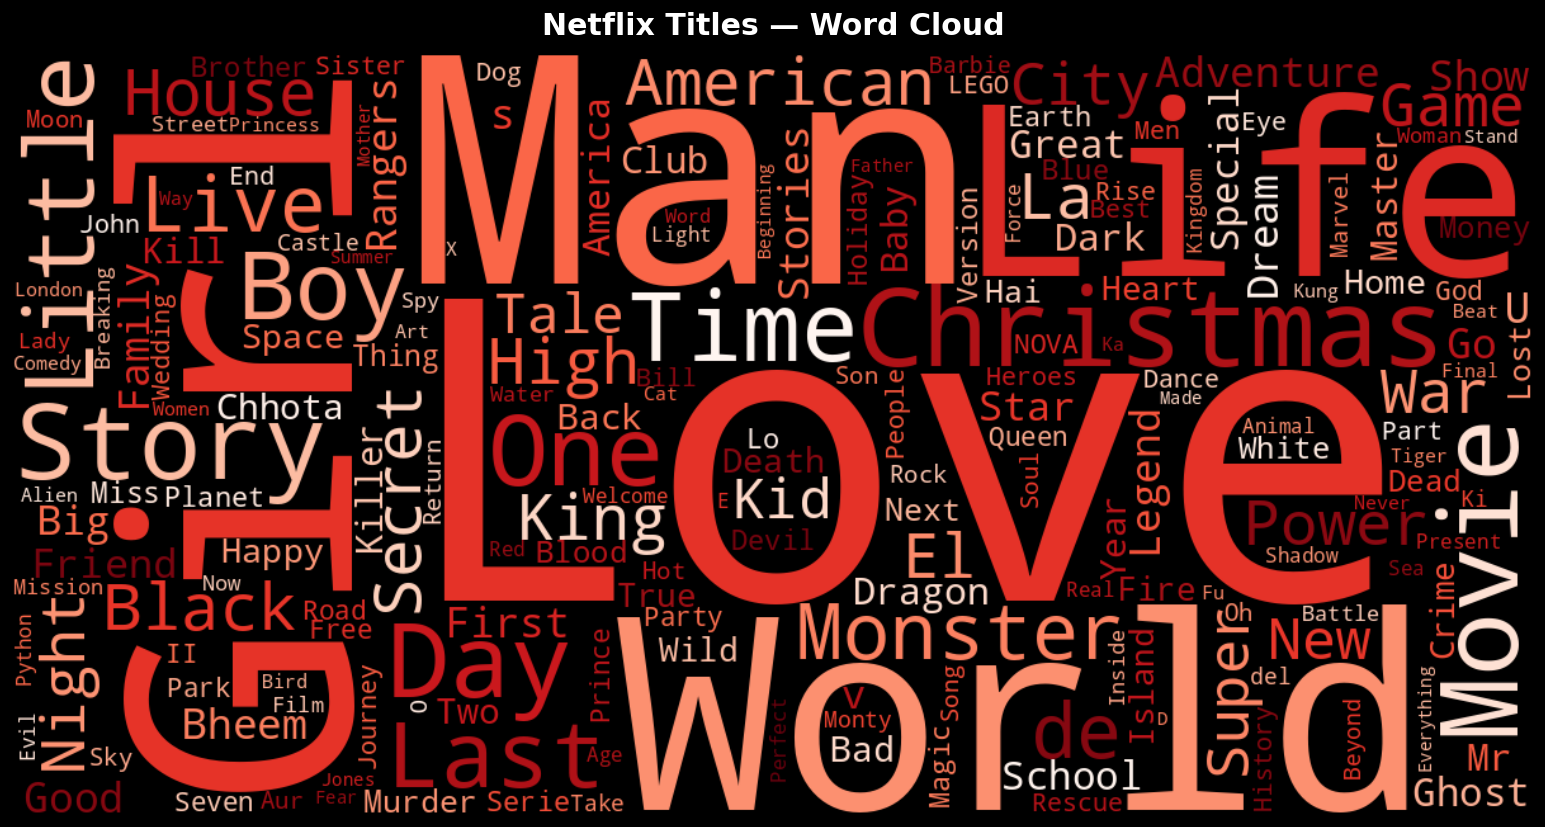

In [83]:
title_text = ' '.join(df['title'].dropna().values)

wc = WordCloud(width=1200, height=600,
               background_color='black',
               colormap='Reds',
               max_words=200,
               collocations=False).generate(title_text)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Netflix Titles — Word Cloud', fontsize=18, fontweight='bold',
             color='white', pad=12)
fig.patch.set_facecolor('black')
plt.tight_layout()
plt.savefig('chart8_wordcloud.png', bbox_inches='tight', facecolor='black')
plt.show()

In [84]:

type_counts      = df['type'].value_counts()
movie_pct        = type_counts['Movie'] / len(df) * 100
show_pct         = type_counts['TV Show'] / len(df) * 100

peak_year        = df['year_added'].value_counts().idxmax()
peak_year_count  = df['year_added'].value_counts().max()

top_country      = df['country'].dropna().str.split(', ').explode().value_counts().index[0]
top_country_n    = df['country'].dropna().str.split(', ').explode().value_counts().iloc[0]

top_rating       = df['rating'].value_counts().index[0]
top_rating_n     = df['rating'].value_counts().iloc[0]

top_genre        = df['listed_in'].str.split(', ').explode().value_counts().index[0]

movies           = df[df['type'] == 'Movie']
avg_duration     = movies['duration_value'].mean()

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
busiest_month    = df['month_name'].value_counts().idxmax()

top_director     = df[df['director'] != 'Unknown']['director'].value_counts().index[0]
top_director_n   = df[df['director'] != 'Unknown']['director'].value_counts().iloc[0]

print("=== YOUR NETFLIX INSIGHT SUMMARY ===\n")
print(f"Total titles analysed : {len(df):,}")
print(f"Movies                : {movie_pct:.1f}%")
print(f"TV Shows              : {show_pct:.1f}%")
print(f"Peak growth year      : {peak_year} ({peak_year_count} titles added)")
print(f"Top producing country : {top_country} ({top_country_n} titles)")
print(f"Most common rating    : {top_rating} ({top_rating_n} titles)")
print(f"Most popular genre    : {top_genre}")
print(f"Avg movie duration    : {avg_duration:.0f} minutes")
print(f"Busiest month         : {busiest_month}")
print(f"Most prolific director: {top_director} ({top_director_n} titles)")

=== YOUR NETFLIX INSIGHT SUMMARY ===

Total titles analysed : 8,794
Movies                : 69.7%
TV Shows              : 30.3%
Peak growth year      : 2019 (2016 titles added)
Top producing country : United States (4510 titles)
Most common rating    : TV-MA (3209 titles)
Most popular genre    : International Movies
Avg movie duration    : 100 minutes
Busiest month         : July
Most prolific director: Rajiv Chilaka (19 titles)


# Netflix Content Analysis — Key Insights
Total titles analysed : 8,794
Movies                : 69.7%
TV Shows              : 30.3%
Peak growth year      : 2019 (2016 titles added)
Top producing country : United States (4510 titles)
Most common rating    : TV-MA (3209 titles)
Most popular genre    : International Movies
Avg movie duration    : 100 minutes
Busiest month         : July
Most prolific director: Rajiv Chilaka (19 titles)

## 1. Netflix is primarily a movie platform
Movies make up roughly **69.7%** of the entire catalog, compared to **30.3%** for TV Shows.
This tells us Netflix built its library heavily around films before expanding
its original TV show production in later years.

## 2. The library grew explosively between 2016 and 2019
The single biggest year for content additions was **2019 **, when Netflix added
over **2016** titles. This aligns with Netflix's global expansion strategy and
its aggressive push into original content production.

## 3. The United States dominates — but the catalog is global
**[United States ]** produces the most content by far with **4510** titles.
However, the presence of India, the UK, Japan, and South Korea in the top 10
shows Netflix's deliberate investment in international and local-language content.

## 4. Content skews toward mature audiences
The most common rating is **[TV-MA]**, suggesting Netflix's primary audience
is adults. Family and children's content exists but is a smaller portion of
the overall library.

## 5. International Movies is the dominant genre
**[International Movies]** is the most represented category, reflecting Netflix's global
content strategy. Dramas and Comedies follow, showing the platform balances
serious and light content.

## 6. The typical Netflix movie is around X hours long
With an average duration of **~100 minutes**, most Netflix movies fall in the
standard feature-film range of 90–120 minutes. The distribution has a long
tail — some documentary and special content runs much shorter or longer.

## 7. Netflix adds the most content in [month]
Content additions spike in **[July]**, likely timed to maximise
subscriber engagement during holiday or high-viewership seasons.

## 8. A handful of directors are very prolific
**[TRajiv Chilaka]** leads with **19** titles, suggesting Netflix has
preferred partnerships with certain filmmakers — particularly in
international markets.

In [85]:
movies = df[df['type'] == 'Movie'].copy()

duration_by_year = (movies.groupby('year_added')['duration_value']
                          .mean()
                          .reset_index())

print("Average movie duration by year:")
print(duration_by_year.to_string(index=False))

first = duration_by_year['duration_value'].iloc[0]
last  = duration_by_year['duration_value'].iloc[-1]
trend = "getting shorter" if last < first else "getting longer"
print(f"\nTrend: Netflix movies have been {trend} over time.")
print(f"From ~{first:.0f} min (earliest) to ~{last:.0f} min (most recent)")

Average movie duration by year:
 year_added  duration_value
       2008       81.000000
       2009       66.500000
       2010       84.000000
       2011       93.461538
       2012       62.000000
       2013       83.500000
       2014       77.000000
       2015       83.571429
       2016       83.613546
       2017       95.680191
       2018      101.739693
       2019       99.923455
       2020      101.585670
       2021      102.839879

Trend: Netflix movies have been getting longer over time.
From ~81 min (earliest) to ~103 min (most recent)


In [86]:
yearly_type = df.groupby(['year_added','type']).size().unstack(fill_value=0)
yearly_type = yearly_type[yearly_type.index >= 2015]

print("Year-by-year growth comparison:")
print(yearly_type)

# Which type grew more from 2016 to peak?
if 'Movie' in yearly_type.columns and 'TV Show' in yearly_type.columns:
    movie_growth = yearly_type['Movie'].pct_change().mean() * 100
    show_growth  = yearly_type['TV Show'].pct_change().mean() * 100
    print(f"\nAvg yearly growth — Movies  : {movie_growth:.1f}%")
    print(f"Avg yearly growth — TV Shows: {show_growth:.1f}%")

Year-by-year growth comparison:
type        Movie  TV Show
year_added                
2015           56       26
2016          251      176
2017          838      349
2018         1237      412
2019         1424      592
2020         1284      595
2021          993      505

Avg yearly growth — Movies  : 102.1%
Avg yearly growth — TV Shows: 120.4%


In [94]:
print("=" * 50)
print("   NETFLIX EDA — PROJECT COMPLETED")
print("=" * 50)
print(f"  Total titles analysed : {len(df):,}")
print(f"  Columns               : {df.shape[1]}")
print(f"  Charts generated      : 8")
print(f"  Key insights          : 8")
print(f"  Files saved           : netflix_clean.csv")
print("=" * 50)

   NETFLIX EDA — PROJECT COMPLETED
  Total titles analysed : 8,794
  Columns               : 17
  Charts generated      : 8
  Key insights          : 8
  Files saved           : netflix_clean.csv
